### Imports

In [1]:
import json
import warnings
from pathlib import Path

import optuna
import torch
import torch.nn as nn

from src.datasets.audio_dataset import AudioDataset
from src.engine import train_one_epoch_cnn, validate_cnn, get_split_dataloaders, benchmark_cnn
from src.models.cnn_2d_classifier import CNN2DClassifier
from src.preprocessing import get_cnn_pipeline
from src.utils import plot_training_history, run_sweep

warnings.filterwarnings("ignore", category=UserWarning)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
MODEL_NAME = CNN2DClassifier.NAME

INPUT_DIR = Path('../../data/audioMNIST')
HYPERPARAMETERS_PATH = Path(f'../../hyperparameters/{MODEL_NAME}.json')
MODEL_PATH = Path(f'../../models/{MODEL_NAME}.pth')

NUM_EPOCHS = 20

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Hyperparameter Tuning

In [4]:
def objective(trial) -> float:
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    dataset = AudioDataset(INPUT_DIR, get_cnn_pipeline())
    train_dataloader, val_dataloader, _ = get_split_dataloaders(dataset)

    model = CNN2DClassifier().to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    val_acc = 0.0
    for epoch in range(3):
        train_one_epoch_cnn(device, model, criterion, optimiser, train_dataloader, leave=False)
        val_loss, val_acc = validate_cnn(device, model, criterion, val_dataloader, leave=False)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc

run_sweep(objective, HYPERPARAMETERS_PATH, 20)

### Training

Features shape: torch.Size([64, 1, 64, 27])
Labels shape: torch.Size([64])

Hyperparameters used: {'lr': 0.007039879588220245}

Training cnn_2d...
[Epoch 1/20]


Validating: 100%|██████████| 47/47 [00:04<00:00, 10.51batches/s]


Train Loss: 0.14 | Train Accuracy: 96.01% | Val Loss: 0.04 | Val Accuracy: 98.57%

[Epoch 2/20]


Validating: 100%|██████████| 47/47 [00:01<00:00, 36.87batches/s]


Train Loss: 0.02 | Train Accuracy: 99.40% | Val Loss: 0.16 | Val Accuracy: 94.67%

[Epoch 3/20]


...

Train Loss: 0.00 | Train Accuracy: 99.84% | Val Loss: 0.00 | Val Accuracy: 99.90%

[Epoch 20/20]


Validating: 100%|██████████| 47/47 [00:01<00:00, 39.91batches/s]

Train Loss: 0.00 | Train Accuracy: 99.93% | Val Loss: 0.01 | Val Accuracy: 99.57%

Best model had an accuracy of 99.90%.
Running final test...



Benchmarking: 100%|██████████| 47/47 [00:01<00:00, 39.06batches/s]


Test Accuracy: 99.90% | Total MACs: 694778


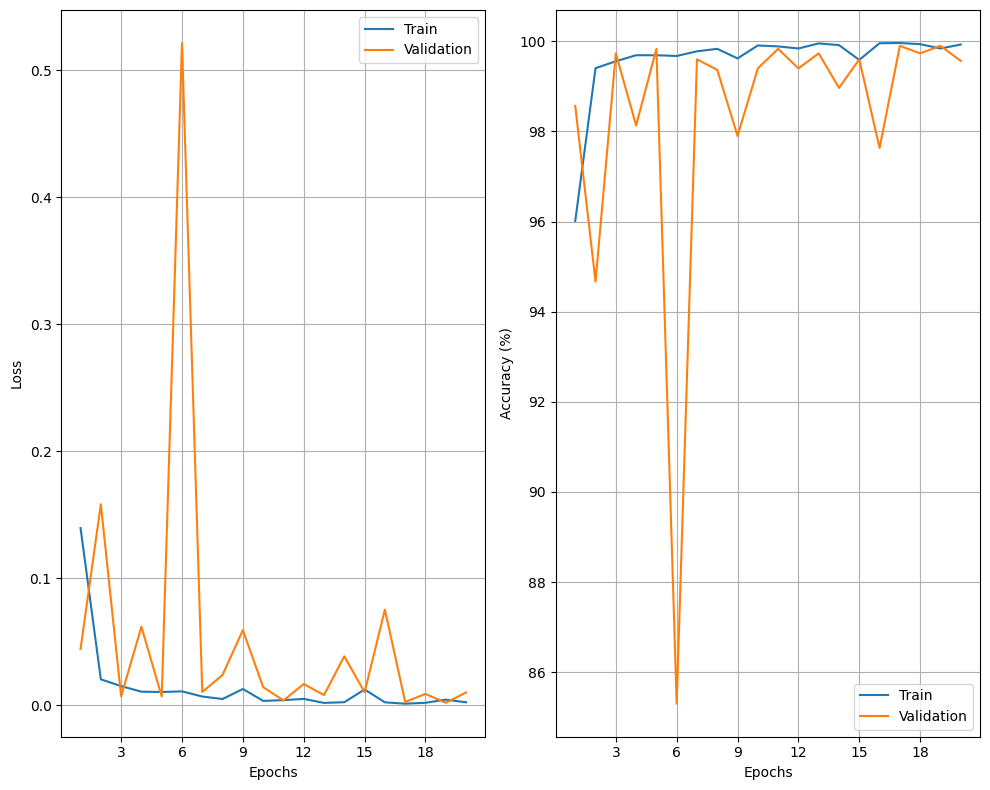

In [5]:
if __name__ == '__main__':
    dataset = AudioDataset(INPUT_DIR, get_cnn_pipeline())
    train_dataloader, val_dataloader, test_dataloader = get_split_dataloaders(dataset)

    # Get one batch from the training loader and make sure it looks good
    features, labels = next(iter(train_dataloader))
    print(f'Features shape: {features.shape}')
    print(f'Labels shape: {labels.shape}')
    print()

    # Load hyperparameters
    hyperparameters = json.load(open(HYPERPARAMETERS_PATH, 'r'))
    print(f'Hyperparameters used: {hyperparameters}')
    print()

    model = CNN2DClassifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hyperparameters['lr'])
    criterion = nn.CrossEntropyLoss()

    print(f'Training {model.NAME}...')
    best_acc = 0.0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    for epoch in range(NUM_EPOCHS):
        print(f'[Epoch {epoch + 1}/{NUM_EPOCHS}]')

        train_loss, train_acc = train_one_epoch_cnn(device, model, criterion, optimizer, train_dataloader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_loss, val_acc = validate_cnn(device, model, criterion, val_dataloader)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)

        print(f'Train Loss: {train_loss:.2f} | Train Accuracy: {train_acc:.2f}% | Val Loss: {val_loss:.2f} | Val Accuracy: {val_acc:.2f}%')
        print()

    print(f'Best model had an accuracy of {best_acc:.2f}%.')
    print(f'Running final test...')
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint, strict=True)
    model.to(device)

    test_accuracy, macs = benchmark_cnn(device, model, test_dataloader)
    print(f'Test Accuracy: {test_accuracy:.2f}% | Total MACs: {macs}')

    plot_training_history(train_losses, train_accs, val_losses, val_accs)